<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# PyTorch

You've written a lot of code in the previous excercises to provide a whole host of neural network functionality. You've also worked hard to make your code efficient and vectorized.

For this excercise, though, we're going to leave behind your beautiful codebase and instead migrate to one of two popular deep learning frameworks: PyTorch.

The original code for this exercise was published as an assignment in the [CS231n](http://cs231n.stanford.edu/index.html) course at Uni Standford. The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Jan
- LastName: Hoegen
- MatriculationNumber: 82358
----------

### What is PyTorch?

PyTorch is a system for executing **dynamic computational graphs** over **Tensor objects** that behave similarly as numpy ndarray. 

It comes with a powerful **automatic differentiation engine** that removes the need for manual **back-propagation**. 

### Why?

* Our code will now run on GPUs! Much faster training. When using a framework like PyTorch or TensorFlow you can harness the power of the GPU for your own custom neural network architectures without having to write CUDA code directly (which is beyond the scope of this class).
* We want you to stand on the shoulders of giants! TensorFlow and PyTorch are both excellent frameworks that will make your lives a lot easier, and now that you understand their guts, you are free to use them :) 
* We want you to be exposed to the sort of deep learning code you might run into in academia or industry.

### PyTorch versions
This notebook assumes that you are using **PyTorch version 1.7**, but don't worry it is already installed in your environment if you are working on one of the P!X3LFLUX servers or using the *.yml file provided via ILIAS.

### How will I learn PyTorch?

This exercise will provide you with a basic understanding of tools within PyTorch. 

Justin Johnson has made an excellent [tutorial](https://pytorch.org/tutorials/beginner/pytorch_with_examples.html) for PyTorch. 
(**Note** We'll focus on the nn part of PyTorch within this exercise, so you may want to skip directly to the nn part of the tutorial.) 
We want to encourage you to browse through the examples within the PyTorch documentation. 

You can also find the detailed [API doc](http://pytorch.org/docs/stable/index.html) here. If you have other questions that are not addressed by the API docs, the [PyTorch forum](https://discuss.pytorch.org/) is a much better place to ask than StackOverflow.

------
# Table of Contents

This excercise has 4 parts. You will learn PyTorch on **two different levels of abstraction**.

1. Preparation: we will use CIFAR-10 dataset.
2. PyTorch Module API: **PyTorch Abstraction level 1**, we will use `nn.Module` to define arbitrary neural network architecture. 
4. PyTorch Sequential API: **PyTorch Abstraction level 2**, we will use `nn.Sequential` to define a linear feed-forward network very conveniently. 
5. CIFAR-10 open-ended challenge: please implement your own network to get as high accuracy as possible on CIFAR-10. You can experiment with any layer, optimizer, hyperparameters or other advanced features. 

Here is a table of comparison:

| API           | Flexibility | Convenience |
|---------------|-------------|-------------|
| Barebone      | High        | Low         |
| `nn.Module`     | High        | Medium      |
| `nn.Sequential` | Low         | High        |

This means PyTorch has different layers of abstraction, each with pros and cons. Nevertheless Barebone PyTorch is not part of this excercise. 

-----
# 1. Preparation

First, we load the CIFAR-10 dataset. This might take a couple minutes the first time you do it, but the files should stay cached after that. You can also copy the CIFAR10 data from a previous excercise into the EITB712M folder manually if you want to save time. 

In previous parts of the assignment we had to write our own code to download the CIFAR-10 dataset, preprocess it, and iterate through it in minibatches; PyTorch provides convenient tools to automate this process for us.

In [1]:
import torch
#assert '.'.join(torch.__version__.split('.')[:2]) == '1.8'
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torch.nn.functional as F  # useful stateless functions

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np
import pynvml as py 

dtype = torch.float32 # we will be using float throughout this tutorial
# Constant to control how frequently we print train loss
print_every = 100

c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
NUM_TRAIN = 49000

# The torchvision.transforms package provides tools for preprocessing data
# and for performing data augmentation; here we set up a transform to
# preprocess the data by subtracting the mean RGB value and dividing by the
# standard deviation of each RGB value; we've hardcoded the mean and std.
transform = T.Compose([
                T.ToTensor(),
                T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
            ])

# We set up a Dataset object for each split (train / val / test); Datasets load
# training examples one at a time, so we wrap each Dataset in a DataLoader which
# iterates through the Dataset and forms minibatches. We divide the CIFAR-10
# training set into train and val sets by passing a Sampler object to the
# DataLoader telling how it should sample from the underlying Dataset.
cifar10_train = dset.CIFAR10('datasets', train=True, download=True, transform=transform)
loader_train = DataLoader(cifar10_train, batch_size=64, sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

cifar10_val = dset.CIFAR10('datasets', train=True, download=True, transform=transform)
loader_val = DataLoader(cifar10_val, batch_size=64, sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

cifar10_test = dset.CIFAR10('datasets', train=False, download=True, transform=transform)
loader_test = DataLoader(cifar10_test, batch_size=64)

## CPU or GPU

As PyTorch can execute on a GPU, the following section detects if there is a Cuda-GPU avaiable.
Otherwise the CPU is used. 

**HINTs** 
- The GPUs are randomly selected to distribute the workload.
- You may want to choose a different GPU or switch the server depending on the workload (e.g. from other students).
- You can use the following command in the shell to see the currect usage: `watch -n 1 -d nvidia-smi`
    - This will simply output all of the available gpus every second and highlights the changes in the command output.
- You can play with the USE_GPU setting to see (and/or measure) the difference in processing time

In [ ]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

12.8
True
NVIDIA GeForce RTX 4060 Ti


In [ ]:
# Helper function to find the GPU with max. free memory left

def get_gpu_with_max_free_mem():
    py.nvmlInit()
    mem_free = np.zeros(torch.cuda.device_count())
    for gpu_index in range(torch.cuda.device_count()):
        handle = py.nvmlDeviceGetHandleByIndex(int(gpu_index))
        mem_info = py.nvmlDeviceGetMemoryInfo(handle)
        mem_free[gpu_index] = mem_info.free // 1024 ** 2
        
    GPU_num = np.argmax(mem_free)
    return GPU_num

In [ ]:
USE_GPU = True

dtype = torch.float32 # we will be using float throughout this tutorial

if USE_GPU and torch.cuda.is_available():
    print('***********************************')
    print('GPU availble! Lets see what we have:')
    print('***********************************')
    !nvidia-smi
    print('***********************************')
    device = torch.device('cuda:' + str(get_gpu_with_max_free_mem()))
    print('Using GPU with max free memory: ' + str(get_gpu_with_max_free_mem()))
    print(device)
    print('***********************************')
else:
    device = torch.device('cpu')
    print('no GPU available, using {} with {} threads'.format(device, torch.get_num_threads()))

***********************************
GPU availble! Lets see what we have:
***********************************
Mon Oct 27 01:26:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   43C    P0             37W /  165W |     852MiB /  16380MiB |      5%      Default |
|                              

## PyTorch Tensors: Flatten Function
A PyTorch Tensor is conceptionally similar to a numpy array: it is an n-dimensional grid of numbers, and like numpy PyTorch provides many functions to efficiently operate on Tensors. As a simple example, we provide a `flatten` function below which reshapes image data for use in a fully-connected neural network.

Recall that image data is typically stored in a Tensor of shape N x C x H x W, where:

* N is the number of datapoints
* C is the number of channels
* H is the height of the intermediate feature map in pixels
* W is the height of the intermediate feature map in pixels

This is the right way to represent the data when we are doing something like a 2D convolution, that needs spatial understanding of where the intermediate features are relative to each other. When we use fully connected affine layers to process the image, however, we want each datapoint to be represented by a single vector -- it's no longer useful to segregate the different channels, rows, and columns of the data. So, we use a "flatten" operation to collapse the `C x H x W` values per representation into a single long vector. The flatten function below first reads in the N, C, H, and W values from a given batch of data, and then returns a "view" of that data. "View" is analogous to numpy's "reshape" method: it reshapes x's dimensions to be N x ??, where ?? is allowed to be anything (in this case, it will be C x H x W, but we don't need to specify that explicitly). 

In [ ]:
def flatten(x):
    N = x.shape[0] # read in N, C, H, W
    return x.view(N, -1)  # "flatten" the C * H * W values into a single vector per image

def test_flatten():
    x = torch.arange(12).view(2, 1, 3, 2)
    print('Before flattening: '), print(x), print()
    print('After flattening: '), print(flatten(x))

test_flatten()

Before flattening: 
tensor([[[[ 0,  1],
          [ 2,  3],
          [ 4,  5]]],


        [[[ 6,  7],
          [ 8,  9],
          [10, 11]]]])

After flattening: 
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])


# 2. PyTorch Module API

Barebone PyTorch requires that we track all the parameter tensors by hand. This is fine for small networks with a few tensors, but it is extremely inconvenient and error-prone to track tens or hundreds of tensors in larger networks.

PyTorch provides the `nn.Module` API for you to define arbitrary network architectures, while tracking every learnable parameters for you. PyTorch also provides the `torch.optim` package that implements all the common optimizers, such as RMSProp, Adagrad, and Adam. It even supports approximate second-order methods like L-BFGS! You can refer to the [doc](http://pytorch.org/docs/master/optim.html) for the exact specifications of each optimizer.

To use the Module API, follow the steps below (also check out the example class TwoFlayerFC below):

1. Subclass `nn.Module`. Give your network class an intuitive name like `TwoLayerFC`. 

2. In the constructor `__init__()`, define all the layers you need as class attributes. Layer objects like `nn.Linear` and `nn.Conv2d` are themselves `nn.Module` subclasses and contain learnable parameters, so that you don't have to instantiate the raw tensors yourself. `nn.Module` will track these internal parameters for you. Refer to the [doc](http://pytorch.org/docs/master/nn.html) to learn more about the dozens of builtin layers. **Warning**: don't forget to call the `super().__init__()` first!

3. In the `forward()` method, define the *connectivity* of your network. You should use the attributes defined in `__init__` as function calls that take tensor as input and output the "transformed" tensor. Do *not* create any new layers with learnable parameters in `forward()`! All of them must be declared upfront in `__init__`. 

After you define your Module subclass, you can instantiate it as an object and call it just like the NN forward function.

### Module API: Two-Layer Network
Here is a concrete example of a 2-layer fully connected network:

In [ ]:
class TwoLayerFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # assign layer objects to class attributes
        self.fc1 = nn.Linear(input_size, hidden_size)
        # nn.init package contains convenient initialization methods
        # http://pytorch.org/docs/master/nn.html#torch-nn-init 
        nn.init.kaiming_normal_(self.fc1.weight)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        nn.init.kaiming_normal_(self.fc2.weight)
    
    def forward(self, x):
        # forward always defines connectivity
        x = flatten(x)
        scores = self.fc2(F.relu(self.fc1(x)))
        return scores

def test_TwoLayerFC():
    input_size = 50
    x = torch.zeros((64, input_size), dtype=dtype)  # minibatch size 64, feature dimension 50
    model = TwoLayerFC(input_size, 42, 10)
    scores = model(x)
    print(scores.size())  # you should see [64, 10]
test_TwoLayerFC()

torch.Size([64, 10])


### Module API: Three-Layer ConvNet

Here is a concrete example of a 3-layer ConvNet followed by a fully connected layer. The detailed network architecture is:

1. Convolutional layer with `channel_1` **5x5** filters with stride=1 and zero-padding=**2**
2. ReLU
3. Convolutional layer with `channel_2` **3x3** filters with stride=1 and zero-padding=**1**
4. ReLU
5. Fully-connected layer to `num_classes` classes

The weight matrices of the model are initialized using the Kaiming normal initialization method.

**More information about conv-nets in PyTorch**: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d

The `test_ThreeLayerConvNet` function will run; it should print `(64, 10)` for the shape of the output scores.

In [ ]:
class ThreeLayerConvNet(nn.Module):
    def __init__(self, in_channel, channel_1, channel_2, num_classes):
        super().__init__()
        # assign layer objects to class attributes
        self.cv1 = nn.Conv2d(in_channel, channel_1, 5, padding=2)
        self.cv2 = nn.Conv2d(channel_1, channel_2, 3, padding=1)
        self.fc1 = nn.Linear(channel_2 * 32 * 32, num_classes)
        # nn.init package contains convenient initialization methods
        # http://pytorch.org/docs/master/nn.html#torch-nn-init 
        nn.init.kaiming_normal_(self.cv1.weight)
        nn.init.kaiming_normal_(self.cv2.weight)
        nn.init.kaiming_normal_(self.fc1.weight)


    def forward(self, x):
        scores = None
        # forward always defines connectivity
        cx1=F.relu(self.cv1(x))
        cx2=F.relu(self.cv2(cx1))
        fx1 = flatten(cx2)
        scores = self.fc1(fx1)
        return scores


def test_ThreeLayerConvNet():
    x = torch.zeros((64, 3, 32, 32), dtype=dtype)  # minibatch size 64, image size [3, 32, 32]
    model = ThreeLayerConvNet(in_channel=3, channel_1=12, channel_2=8, num_classes=10)
    scores = model(x)
    print(scores.size())  # you should see [64, 10]
    
test_ThreeLayerConvNet()

torch.Size([64, 10])


<span style="color:blue">**Write down the sizes of each layer. How is padding and stride used in the conv2d layers?**</span>

Answer: ...

> - Input: 64, 3, 32, 32
> - Layer 1: Conv: 64, 12, 32, 32. Mit padding bleibt 32x32 erhalten
> - Layer 2: Conv: 64, 8, 32, 32. Mit padding bleibt 32x32 erhalten
> - Flatten: 64, 8192
> - Layer 3: Linear: 64, 10

### Module API: Check Accuracy
Given the validation or test set, we can check the classification accuracy of a neural network. 

The following function allows us to get the accuracy for a data set (provided via a data loader) and a model.

<span style="color:blue">**You don't have to write code, but it's important that you look through and understand the code.**</span>

In [ ]:
def check_accuracy_part34(loader, model):
    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')   
    num_correct = 0
    num_samples = 0
    model.eval()  # set model to evaluation mode
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))
    return acc

### Module API: Training Loop
The training loops abstracts the notion of an optimization algorithm and provides implementations of most of the algorithms commonly used to optimize neural networks. We'll use this function throughout the rest of this excercise several times. 

<span style="color:blue">**You don't have to write code, but it's important that you look through and understand the code.**</span>

In [ ]:
def train_part34(model, optimizer, epochs=1, debug=True):
    """
    Train a model on CIFAR-10 using the PyTorch Module API.
    
    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - epochs: (Optional) A Python integer giving the number of epochs to train for
    
    Returns: Nothing, but prints model accuracies during training.
    """

    model = model.to(device=device)  # move the model parameters to CPU/GPU
    for e in range(epochs):
        for t, (x, y) in enumerate(loader_train):
            model.train()  # put model to training mode
            
            # move data and labels to device, e.g. GPU
            x = x.to(device=device, dtype=dtype)  
            y = y.to(device=device, dtype=torch.long)

            # calculate all the scores
            scores = model(x)
            loss = F.cross_entropy(scores, y)

            # Zero out all of the gradients for the variables which the optimizer will update.
            # This is required as PyTorch accumulates the gradients on subsequent backward passes. 
            optimizer.zero_grad()

            # This is the backwards pass: compute the gradient of the loss with respect to each parameter of the model.
            loss.backward()

            # Actually update the parameters of the model using the gradients computed by the backwards pass.
            optimizer.step()

            if debug:
                if t % print_every == 0:
                    print('Epoch %d, Iteration %d, loss = %.4f' % (e, t, loss.item()))
                    check_accuracy_part34(loader_val, model)
                    print()

### Module API: Train a Two-Layer Network
Now we are ready to run the training loop.

Simply pass the input size, hidden layer size, and number of classes (i.e. output size) to the constructor of `TwoLayerFC`. 

You also need to define an optimizer that tracks all the learnable parameters inside `TwoLayerFC`.

You don't need to tune any hyperparameters, but you should see model accuracies above 40% after training for one epoch.

In [ ]:
hidden_layer_size = 4000
learning_rate_search = 1e-2
model = TwoLayerFC(3 * 32 * 32, hidden_layer_size, 10)
optimizer = optim.SGD(model.parameters(), lr=learning_rate_search)

train_part34(model, optimizer)

Epoch 0, Iteration 0, loss = 3.2996
Checking accuracy on validation set
Got 144 / 1000 correct (14.40)

Epoch 0, Iteration 100, loss = 2.2812
Checking accuracy on validation set
Got 352 / 1000 correct (35.20)

Epoch 0, Iteration 200, loss = 2.6775
Checking accuracy on validation set
Got 346 / 1000 correct (34.60)

Epoch 0, Iteration 300, loss = 1.9757
Checking accuracy on validation set
Got 352 / 1000 correct (35.20)

Epoch 0, Iteration 400, loss = 2.1527
Checking accuracy on validation set
Got 434 / 1000 correct (43.40)

Epoch 0, Iteration 500, loss = 1.9549
Checking accuracy on validation set
Got 400 / 1000 correct (40.00)

Epoch 0, Iteration 600, loss = 2.2464
Checking accuracy on validation set
Got 391 / 1000 correct (39.10)

Epoch 0, Iteration 700, loss = 1.7748
Checking accuracy on validation set
Got 443 / 1000 correct (44.30)



### Module API: Train a Three-Layer ConvNet
You should now use the Module API to train a three-layer ConvNet on CIFAR. This should look very similar to training the two-layer network! You don't need to tune any hyperparameters, but you should achieve above above 45% after training for one epoch.

You should train the model using stochastic gradient descent without momentum.

In [ ]:
learning_rate_search = 3e-3
channel_1 = 32
channel_2 = 16

model = None
optimizer = None
################################################################################
# TODO: Instantiate your ThreeLayerConvNet model and a corresponding optimizer #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

# ** HINT: It is only one line of code! **
model = ThreeLayerConvNet(3, channel_1, channel_2, 10)
optimizer = optim.SGD(model.parameters(), lr=learning_rate_search)

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                                 END OF YOUR CODE                             
################################################################################

optimizer = optim.SGD(model.parameters(), lr=learning_rate_search)
train_part34(model, optimizer)

Epoch 0, Iteration 0, loss = 3.7239
Checking accuracy on validation set
Got 81 / 1000 correct (8.10)

Epoch 0, Iteration 100, loss = 1.9416
Checking accuracy on validation set
Got 341 / 1000 correct (34.10)

Epoch 0, Iteration 200, loss = 1.5168
Checking accuracy on validation set
Got 388 / 1000 correct (38.80)

Epoch 0, Iteration 300, loss = 1.6426
Checking accuracy on validation set
Got 410 / 1000 correct (41.00)

Epoch 0, Iteration 400, loss = 1.6428
Checking accuracy on validation set
Got 430 / 1000 correct (43.00)

Epoch 0, Iteration 500, loss = 1.5833
Checking accuracy on validation set
Got 455 / 1000 correct (45.50)

Epoch 0, Iteration 600, loss = 1.5018
Checking accuracy on validation set
Got 441 / 1000 correct (44.10)

Epoch 0, Iteration 700, loss = 1.6575
Checking accuracy on validation set
Got 456 / 1000 correct (45.60)



# 3. PyTorch Sequential API

Part 2 introduced the PyTorch Module API, which allows you to define arbitrary learnable layers and their connectivity. 

For simple models like a stack of feed forward layers, you still need to go through 3 steps: subclass `nn.Module`, assign layers to class attributes in `__init__`, and call each layer one by one in `forward()`. Is there a more convenient way? 

Fortunately, PyTorch provides a container Module called `nn.Sequential`, which merges the above steps into one. It is not as flexible as `nn.Module`, because you cannot specify more complex topology than a feed-forward stack, but it's good enough for many use cases.

### Sequential API: Two-Layer Network
Let's see how to rewrite our two-layer fully connected network example with `nn.Sequential`, and train it using the training loop defined above.

Again, you don't need to tune any hyperparameters here, but you shoud achieve above 40% accuracy after one epoch of training.

In [ ]:
# We need to wrap `flatten` function in a module in order to stack it
# in nn.Sequential
class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

hidden_layer_size = 4000
learning_rate_search = 1e-2

model = nn.Sequential(
    Flatten(),
    nn.Linear(3 * 32 * 32, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)

# you can use Nesterov momentum in optim.SGD
optimizer = optim.SGD(model.parameters(), lr=learning_rate_search,
                     momentum=0.9, nesterov=True)

train_part34(model, optimizer)

Epoch 0, Iteration 0, loss = 2.3367
Checking accuracy on validation set
Got 195 / 1000 correct (19.50)

Epoch 0, Iteration 100, loss = 1.5796
Checking accuracy on validation set
Got 413 / 1000 correct (41.30)

Epoch 0, Iteration 200, loss = 2.1768
Checking accuracy on validation set
Got 410 / 1000 correct (41.00)

Epoch 0, Iteration 300, loss = 1.7942
Checking accuracy on validation set
Got 419 / 1000 correct (41.90)

Epoch 0, Iteration 400, loss = 1.4422
Checking accuracy on validation set
Got 436 / 1000 correct (43.60)

Epoch 0, Iteration 500, loss = 1.7830
Checking accuracy on validation set
Got 412 / 1000 correct (41.20)

Epoch 0, Iteration 600, loss = 1.7055
Checking accuracy on validation set
Got 452 / 1000 correct (45.20)

Epoch 0, Iteration 700, loss = 1.7979
Checking accuracy on validation set
Got 447 / 1000 correct (44.70)



### Sequential API: Three-Layer ConvNet

Using `nn.Sequential` we can rewrite the three-layer ConvNet architecture from Part 2. The network architecture is the same:**</span>

1. Convolutional layer with `channel_1` **5x5** filters with stride=1 and zero-padding=**2**
2. ReLU
3. Convolutional layer with `channel_2` **3x3** filters with stride=1 and zero-padding=**1**
4. ReLU
5. Fully-connected layer to `num_classes` classes

For optimizing the model stochastic gradient descent with Nesterov momentum 0.9 is used.

Again, you don't need to tune any hyperparameters but you should see accuracy above 55% after one epoch of training.

In [ ]:
channel_1 = 32
channel_2 = 16
learning_rate_search = 1e-2

model = None
optimizer = None

model = nn.Sequential(
    nn.Conv2d(3, channel_1, 5, padding=2),
    nn.ReLU(),
    nn.Conv2d(channel_1, channel_2, 3, padding=1),
    nn.ReLU(),
    Flatten(),
    nn.Linear(channel_2 * 32 * 32, 10)
)

# you can use Nesterov momentum in optim.SGD
optimizer = optim.SGD(model.parameters(), lr=learning_rate_search, momentum=0.9, nesterov=True)

train_part34(model, optimizer)

Epoch 0, Iteration 0, loss = 2.2958
Checking accuracy on validation set
Got 131 / 1000 correct (13.10)

Epoch 0, Iteration 100, loss = 1.6458
Checking accuracy on validation set
Got 411 / 1000 correct (41.10)

Epoch 0, Iteration 200, loss = 1.4596
Checking accuracy on validation set
Got 473 / 1000 correct (47.30)

Epoch 0, Iteration 300, loss = 1.5031
Checking accuracy on validation set
Got 493 / 1000 correct (49.30)

Epoch 0, Iteration 400, loss = 1.5956
Checking accuracy on validation set
Got 525 / 1000 correct (52.50)

Epoch 0, Iteration 500, loss = 1.4797
Checking accuracy on validation set
Got 583 / 1000 correct (58.30)

Epoch 0, Iteration 600, loss = 1.3805
Checking accuracy on validation set
Got 575 / 1000 correct (57.50)

Epoch 0, Iteration 700, loss = 1.1177
Checking accuracy on validation set
Got 577 / 1000 correct (57.70)



<span style="color:blue">**Compare the implementation to the module API. Where do you see differences? What is more/less convinient?**</span>

Answer: ...

> - keine weight initialisierung notwendig
> - keine zuweisung der modelle auf self. notwendig
> - kein zusätzlich expliziter vorwärtspfad
> - kein wissen über python klassen definition notwendig 


# 4. CIFAR-10 open-ended challenge

In this section, you can experiment with whatever ConvNet architecture you'd like on CIFAR-10. 

Now it's your job to experiment with architectures, hyperparameters, loss functions, and optimizers to train a model that achieves **at least 70%** accuracy on the CIFAR-10 **validation** set within 10 epochs. You can use the check_accuracy and train functions from above. You can use either `nn.Module` or `nn.Sequential` API. 

<span style="color:blue">**Describe what you did at the end of this notebook.**</span>

Here are the official API documentation for each component.

* Layers in torch.nn package: http://pytorch.org/docs/stable/nn.html
* Activations: http://pytorch.org/docs/stable/nn.html#non-linear-activations
* Loss functions: http://pytorch.org/docs/stable/nn.html#loss-functions
* Optimizers: http://pytorch.org/docs/stable/optim.html


### Things you might try:
- **Filter size**: Above we used 5x5; would smaller filters be more efficient?
- **Number of filters**: Above we used 32 filters. Do more or fewer do better?
- **Pooling vs Strided Convolution**: Do you use max pooling or just stride convolutions?
- **Batch normalization**: Try adding spatial batch normalization after convolution layers and vanilla batch normalization after affine layers. Do your networks train faster?
- **Network architecture**: The network above has two layers of trainable parameters. Can you do better with a deep network? Good architectures to try include:
    - [conv-relu-pool]xN -> [affine]xM -> [softmax or SVM]
    - [conv-relu-conv-relu-pool]xN -> [affine]xM -> [softmax or SVM]
    - [batchnorm-relu-conv]xN -> [affine]xM -> [softmax or SVM]
- **Global Average Pooling**: Instead of flattening and then having multiple affine layers, perform convolutions until your image gets small (7x7 or so) and then perform an average pooling operation to get to a 1x1 image picture (1, 1 , Filter#), which is then reshaped into a (Filter#) vector. This is used in [Google's Inception Network](https://arxiv.org/abs/1512.00567) (See Table 1 for their architecture).
- **Regularization**: Add l2 weight regularization, or perhaps use Dropout.

### Tips for training
For each network architecture that you try, you should tune the learning rate and other hyperparameters. When doing this there are a couple important things to keep in mind:

- If the parameters are working well, you should see improvement within a few hundred iterations
- Remember the coarse-to-fine approach for hyperparameter tuning: start by testing a large range of hyperparameters for just a few training iterations to find the combinations of parameters that are working at all.
- Once you have found some sets of parameters that seem to work, search more finely around these parameters. You may need to train for more epochs.
- You should use the validation set for hyperparameter search, and save your test set for evaluating your architecture on the best parameters as selected by the validation set.

### Going above and beyond
If you are feeling adventurous there are many other features you can implement to try and improve your performance. You are **not required** to implement any of these, but don't miss the fun if you have time!

- Alternative optimizers: you can try Adam, Adagrad, RMSprop, etc.
- Alternative activation functions such as leaky ReLU, parametric ReLU, ELU, or MaxOut.
- Model ensembles
- Data augmentation
- New Architectures
  - [ResNets](https://arxiv.org/abs/1512.03385) where the input from the previous layer is added to the output.
  - [DenseNets](https://arxiv.org/abs/1608.06993) where inputs into previous layers are concatenated together.
  - [This blog has an in-depth overview](https://chatbotslife.com/resnets-highwaynets-and-densenets-oh-my-9bb15918ee32)

### Have fun and happy training! 

In [ ]:
################################################################################
# TODO:                                                                        #         
# Experiment with any architectures, optimizers, and hyperparameters.          #
# Achieve AT LEAST 70% accuracy on the *validation set* within 10 epochs.      #
#                                                                              #
# Note that you can use the check_accuracy function to evaluate on either      #
# the test set or the validation set, by passing either loader_test or         #
# loader_val as the second argument to check_accuracy. You should not touch    #
# the test set until you have finished your architecture and  hyperparameter   #
# tuning, and only run the test set once at the end to report a final value.   #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as T
from torch.utils.data import DataLoader, SubsetRandomSampler
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from itertools import product
import copy
import math
import numpy as np
import optuna

# _________________________________________________
# Device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
print("Using device:", device)

# _________________________________________________
# Constants

NUM_TRAIN = 49000
BATCH_SIZE = 256
NUM_WORKERS = 12
# MAX_ROUNDS = 3
NUM_EPOCHS = 10  # per trial
NUM_TRIALS = 20

iters_per_epoch = np.ceil(NUM_TRAIN / BATCH_SIZE)

RANDOM_SEED = 0
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# _________________________________________________
# Load Dataset
transform_train = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_val_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

cifar10_train = dset.CIFAR10('datasets', train=True, download=True, transform=transform_train)
cifar10_val_test = dset.CIFAR10('datasets', train=True, download=True, transform=transform_val_test)
cifar10_test = dset.CIFAR10('datasets', train=False, download=True, transform=transform_val_test)

indices = np.arange(len(cifar10_train))
np.random.shuffle(indices)
train_idx = indices[:NUM_TRAIN]
val_idx = indices[NUM_TRAIN:]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

loader_train = DataLoader(
    cifar10_train,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

loader_val = DataLoader(
    cifar10_val_test,
    batch_size=BATCH_SIZE,
    sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print(f"Train batches: {len(loader_train)}, Val batches: {len(loader_val)}")
print(f"Results in {iters_per_epoch} iterations per epoch.")

# _________________________________________________
# Helper Functions

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    num_epochs=10,
    criterion=None,
    device=None,
    print_every=20,
    patience=3,
    accumulation_steps=1,
    scheduler=None
):
    """
    Optimized training function with AMP, early stopping, gradient accumulation, 
    best model saving, and optional scheduler.
    """
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # model.to(device)
    # device_type = 'cuda' if device.type == 'cuda' else 'cpu'

    criterion = criterion or F.cross_entropy
    optimizer = optimizer
    scaler = GradScaler()

    best_val_acc = -float('inf')
    best_model = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad() if accumulation_steps == 1 else None

            with autocast("cuda"):
                outputs = model(x)
                loss = criterion(outputs, y) / accumulation_steps  # scale loss for accumulation

            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            running_loss += loss.item() * accumulation_steps
            if (i + 1) % print_every == 0:
                print(f"Epoch {epoch+1}, Iter {i+1}, Avg Loss: {running_loss/print_every:.4f}")
                running_loss = 0.0

        # Step scheduler at epoch end
        if scheduler is not None:
            scheduler.step()

        # Validation check
        val_acc = get_accuracy(val_loader, model, f"Validation Epoch {epoch+1}", device)
        get_accuracy(train_loader, model, f"Training Epoch {epoch+1}", device=device)

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = copy.deepcopy(model)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    return best_model if best_model else model


def get_accuracy(loader, model, name="Validation", device=device, debug=True):
    """
    Compute accuracy of the model on a given DataLoader.
    """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast("cuda"):
                scores = model(x)
            preds = scores.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total
    if debug:
        print(f"{name} Accuracy: {100*acc:.2f}%")
    return acc

# _________________________________________________
# Neural Network

best_model = None
best_val_acc = -float('inf')

def objective(trial):
    global best_model, best_val_acc

    ch1 = trial.suggest_categorical("ch1", [16, 32, 64])
    ch2 = trial.suggest_categorical("ch2", [32, 64, 128])
    ch3 = trial.suggest_categorical("ch3", [32, 64, 128])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)        
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    
    # Build model
    model = nn.Sequential(
        nn.Conv2d(3, ch1, 5, padding=2),
        nn.BatchNorm2d(ch1),
        nn.ReLU(),

        nn.Conv2d(ch1, ch2, 3, padding=1),
        nn.BatchNorm2d(ch2),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(ch2, ch3, 3, padding=1),
        nn.BatchNorm2d(ch3),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Flatten(),
        nn.Linear(ch3 * 8 * 8, 128),
        nn.ReLU(),
        nn.Dropout(0.25),
        nn.Linear(128, 10)
    ).to(device)
            
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    trained_model = train_model(
        model=model,
        train_loader=loader_train,
        val_loader=loader_val,
        num_epochs=NUM_EPOCHS,
        device=device,
        print_every=len(loader_train) // 4,
        patience=2,
        optimizer=optimizer,
        scheduler=scheduler,
    )
    
    val_acc = get_accuracy(loader_val, trained_model, device=device, debug=False)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = copy.deepcopy(trained_model)
        print(f"✅ Found new best model: {100*val_acc:.2f}")
    
    # print(f"Trial {trial+1}: ch1={ch1}, ch2={ch2}, lr={lr}, val_acc={100*val_acc:.2f}%")
    # trial += 1
    
    return val_acc

# _________________________________________________
# Run Bayesian Search

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=NUM_TRIALS) 

best_trial = study.best_trial
print("Best hyperparameters:", best_trial.params)
print(f"Best validation accuracy: {100*best_trial.value:.2f}%")

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                                 END OF YOUR CODE                             
################################################################################
# you can use Nesterov momentum in optim.SGD
# You should get at least 70% accuracy

c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0


[I 2025-10-27 01:40:18,583] A new study created in memory with name: no-name-50fa4edf-7245-47e2-a195-e23c21dbacd2


Train batches: 48, Val batches: 1
Results in 48.0 iterations per epoch.
Epoch 1, Iter 12, Avg Loss: 2.2533
Epoch 1, Iter 24, Avg Loss: 2.1230
Epoch 1, Iter 36, Avg Loss: 2.0390
Epoch 1, Iter 48, Avg Loss: 1.9854
Validation Epoch 1 Accuracy: 31.70%
Training Epoch 1 Accuracy: 32.49%
Epoch 2, Iter 12, Avg Loss: 1.9190
Epoch 2, Iter 24, Avg Loss: 1.8673
Epoch 2, Iter 36, Avg Loss: 1.8199
Epoch 2, Iter 48, Avg Loss: 1.7779
Validation Epoch 2 Accuracy: 41.20%
Training Epoch 2 Accuracy: 40.23%
Epoch 3, Iter 12, Avg Loss: 1.7250
Epoch 3, Iter 24, Avg Loss: 1.6984
Epoch 3, Iter 36, Avg Loss: 1.6795
Epoch 3, Iter 48, Avg Loss: 1.6681
Validation Epoch 3 Accuracy: 45.20%
Training Epoch 3 Accuracy: 44.03%
Epoch 4, Iter 12, Avg Loss: 1.6336
Epoch 4, Iter 24, Avg Loss: 1.6240
Epoch 4, Iter 36, Avg Loss: 1.6037
Epoch 4, Iter 48, Avg Loss: 1.5735
Validation Epoch 4 Accuracy: 45.70%
Training Epoch 4 Accuracy: 45.92%
Epoch 5, Iter 12, Avg Loss: 1.5642
Epoch 5, Iter 24, Avg Loss: 1.5621
Epoch 5, Iter 36, 

[I 2025-10-27 01:42:01,132] Trial 0 finished with value: 0.523 and parameters: {'ch1': 128, 'ch2': 32, 'ch3': 64, 'lr': 3.880740050506618e-05, 'weight_decay': 0.00022133717987999412}. Best is trial 0 with value: 0.523.


...

Training Epoch 8 Accuracy: 41.99%
Early stopping triggered after 8 epochs.
Epoch 1, Iter 12, Avg Loss: 2.1604
Epoch 1, Iter 24, Avg Loss: 1.9392
Epoch 1, Iter 36, Avg Loss: 1.8290
Epoch 1, Iter 48, Avg Loss: 1.7615
Validation Epoch 1 Accuracy: 40.70%
Training Epoch 1 Accuracy: 39.90%
Epoch 2, Iter 12, Avg Loss: 1.6986
Epoch 2, Iter 24, Avg Loss: 1.6648
Epoch 2, Iter 36, Avg Loss: 1.6088
Epoch 2, Iter 48, Avg Loss: 1.5880
Validation Epoch 2 Accuracy: 47.30%
Training Epoch 2 Accuracy: 46.19%
Epoch 3, Iter 12, Avg Loss: 1.5575
Epoch 3, Iter 24, Avg Loss: 1.5299
Epoch 3, Iter 36, Avg Loss: 1.4977
Epoch 3, Iter 48, Avg Loss: 1.4721
Validation Epoch 3 Accuracy: 52.40%
Training Epoch 3 Accuracy: 50.13%
Epoch 4, Iter 12, Avg Loss: 1.4679
Epoch 4, Iter 24, Avg Loss: 1.4489
Epoch 4, Iter 36, Avg Loss: 1.4388
Epoch 4, Iter 48, Avg Loss: 1.4351
Validation Epoch 4 Accuracy: 53.70%
Training Epoch 4 Accuracy: 51.92%
Epoch 5, Iter 12, Avg Loss: 1.3948
Epoch 5, Iter 24, Avg Loss: 1.3990
Epoch 5, Iter 3

[I 2025-10-27 01:59:03,214] Trial 18 finished with value: 0.598 and parameters: {'ch1': 64, 'ch2': 64, 'ch3': 128, 'lr': 7.57972818329132e-05, 'weight_decay': 3.782954651140754e-05}. Best is trial 14 with value: 0.702.


Training Epoch 10 Accuracy: 57.66%
Epoch 1, Iter 12, Avg Loss: 2.1884
Epoch 1, Iter 24, Avg Loss: 1.9030
Epoch 1, Iter 36, Avg Loss: 1.7654
Epoch 1, Iter 48, Avg Loss: 1.6584
Validation Epoch 1 Accuracy: 45.50%
Training Epoch 1 Accuracy: 43.60%
Epoch 2, Iter 12, Avg Loss: 1.5807
Epoch 2, Iter 24, Avg Loss: 1.5221
Epoch 2, Iter 36, Avg Loss: 1.4873
Epoch 2, Iter 48, Avg Loss: 1.4478
Validation Epoch 2 Accuracy: 50.40%
Training Epoch 2 Accuracy: 49.82%
Epoch 3, Iter 12, Avg Loss: 1.4186
Epoch 3, Iter 24, Avg Loss: 1.3741
Epoch 3, Iter 36, Avg Loss: 1.3308
Epoch 3, Iter 48, Avg Loss: 1.2909
Validation Epoch 3 Accuracy: 55.30%
Training Epoch 3 Accuracy: 54.42%
Epoch 4, Iter 12, Avg Loss: 1.2745
Epoch 4, Iter 24, Avg Loss: 1.2526
Epoch 4, Iter 36, Avg Loss: 1.2320
Epoch 4, Iter 48, Avg Loss: 1.1949
Validation Epoch 4 Accuracy: 61.50%
Training Epoch 4 Accuracy: 58.31%
Epoch 5, Iter 12, Avg Loss: 1.1800
Epoch 5, Iter 24, Avg Loss: 1.1711
Epoch 5, Iter 36, Avg Loss: 1.1564
Epoch 5, Iter 48, Av

[I 2025-10-27 01:59:44,053] Trial 19 finished with value: 0.714 and parameters: {'ch1': 64, 'ch2': 64, 'ch3': 64, 'lr': 0.0009389859005283305, 'weight_decay': 2.8664626304079016e-06}. Best is trial 19 with value: 0.714.


Training Epoch 10 Accuracy: 68.00%
✅ Found new best model: 71.40
Best hyperparameters: {'ch1': 64, 'ch2': 64, 'ch3': 64, 'lr': 0.0009389859005283305, 'weight_decay': 2.8664626304079016e-06}
Best validation accuracy: 71.40%


## Describe what you did 

<span style="color:blue">**In the cell below you should write an explanation of what you did, any additional features that you implemented, and/or any graphs that you made in the process of training and evaluating your network.**</span>

- batch size angepasst, um Speicher auszulasten
- anzahl threads für den dataloader erhöht
- CUDA parallelisierung eingepflegt
- early stopping implementiert: breche aktuelle hyperparameter ab, wenn nach mehreren epochen keine besserung eintritt.
- Modell: 3 conv Schichten, Max Pool und Batch Normalization hinzugefügt. Für 2 linear Schichten Tiefe geflattet. Dropout verringert anzahl verbundener Neuronen in Fully connected Layer.
- beste hyperparamter finden mit bayesian search. Default einstellen von optuna. Erstellt modellfunktion zwischen validation acc und hyperparameter. Neue werte so gewählt, dass das Modell verbessert wird. 

## Test set -- **run this only once**

Now that we've gotten a result we're happy with, we test our final model on the test set (which you should store in best_model). Think about how this compares to your validation set accuracy.

In [ ]:
# best_model = model
check_accuracy_part34(loader_test, best_model)

NameError: name 'loader_test' is not defined

In [ ]:
from torchsummary import summary

summary(best_model, input_size=(3, 32, 32))  # CIFAR-10 images are 3x32x32


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]           2,432
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 16, 32, 32]           4,624
              ReLU-4           [-1, 16, 32, 32]               0
           Flatten-5                [-1, 16384]               0
            Linear-6                   [-1, 10]         163,850
Total params: 170,906
Trainable params: 170,906
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.88
Params size (MB): 0.65
Estimated Total Size (MB): 1.54
----------------------------------------------------------------


In [ ]:
from torchviz import make_dot

x = torch.randn(1, 3, 32, 32).to(device)  # dummy input
y = best_model(x)
dot = make_dot(y, params=dict(best_model.named_parameters()))
dot.format = 'png'
dot.render('model_graph')


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

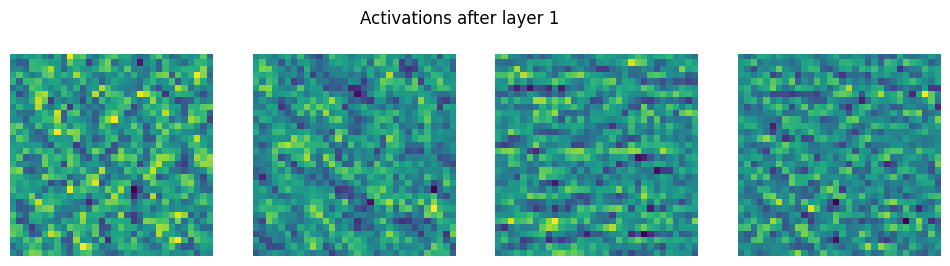

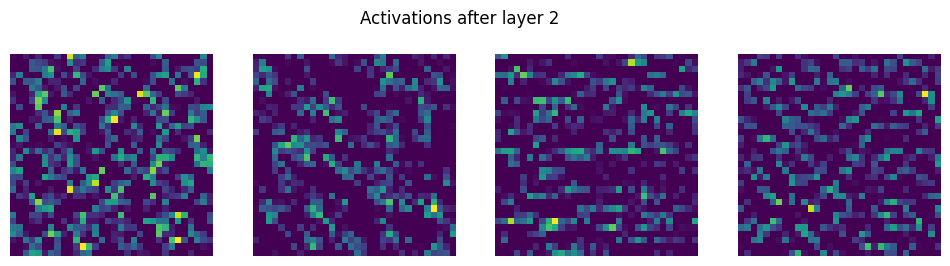

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x32 and 16384x10)

In [ ]:
import matplotlib.pyplot as plt

x = torch.randn(1, 3, 32, 32).to(device)

# Pick a few layers to visualize
layers = [best_model[0], best_model[3], best_model[5]]  # conv layers

for i, layer in enumerate(layers):
    x = layer(x)  # forward through layer
    # Take first image in batch, first 4 feature maps
    activations = x[0, :4].detach().cpu()
    fig, axes = plt.subplots(1, 4, figsize=(12,3))
    for j in range(4):
        axes[j].imshow(activations[j], cmap='viridis')
        axes[j].axis('off')
    plt.suptitle(f'Activations after layer {i+1}')
    plt.show()


In [ ]:
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.save_checkpoint();'))

import helpers

helpers.prepare_submission(additional=[r"EITB712M", r"datasets\cifar-10-batches-py"])

<IPython.core.display.Javascript object>

'Abgaben\\82358_Hoegen_Jan_09_20251027_0055.zip'